# **Test d'Ipotesi**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
"""
Supponiamo che il team marketing dell'e-commerce stia valutando dove concentrare il prossimo aumento di budget per le campagne a pagamento. 
Dall'analisi iniziale emerge che la Germania mostra un conversion rate per l'ultimo anno completo (2025) leggermente superiore rispetto alla Cina, 
ma la differenza è relativamente piccola e non è chiaro se sia dovuta al caso oppure rifletta un reale vantaggio del mercato tedesco.
Il responsabile chiede quindi di verificare in modo rigoroso se questa differenza sia statisticamente significativa, 
così da poter giustificare (o meno) una riallocazione del budget verso la Germania. 
Per evitare di fare affidamento su ipotesi forti sulla distribuzione dei dati, decidiamo di utilizzare un permutation test sul conversion rate tra Germania e Cina, 
confrontando la differenza osservata con quella che otterremmo riassegnando casualmente le etichette di Paese alle sessioni.
"""

In [ ]:
""" 
H₀: Sotto l'ipotesi nulla, il conversion rate della Germania e quello della Cina sono uguali.  
Qualsiasi differenza osservata è attribuibile al caso.
H₁: Sotto l'ipotesi alternativa, i due Paesi hanno conversion rate diversi.  
La differenza osservata non è compatibile con il caso.
"""

In [21]:
events_clean=pd.read_csv("..\\data\\clean_data\\events_clean.csv")

In [22]:
# Filtra solo l'anno 2025 
events_2025 = events_clean[events_clean["year"] == 2025].copy()

In [23]:
# Filtriamo i due Paesi
country1 = "Germany"
country2 = "China"
subset = events_2025[events_2025["country"].isin([country1, country2])].copy()

In [24]:
# Creiamo la variabile binaria di conversione e il vettore dei gruppi
subset["converted"] = (subset["event_type"] == "purchase").astype(int)
subset["group"] = subset["country"]

In [25]:
# Osserviamo i Conversion rate
cr_germany = subset[subset["country"] == country1]["converted"].mean()
cr_china   = subset[subset["country"] == country2]["converted"].mean()

print(f"Conversion rate Germania: {cr_germany:.4f}")
print(f"Conversion rate Cina: {cr_china:.4f}")

Conversion rate Germania: 0.4975
Conversion rate Cina: 0.4734


In [26]:
# Estraiamo i vettori per il test
y = subset["converted"].values      # 0/1
g = subset["group"].values          # Germany / China

In [27]:
# Calcoliamo la differenza che useremo come statistica del test:
obs_diff = cr_germany - cr_china
obs_diff

np.float64(0.024079276025430862)

In [ ]:
"""
Il permutation test risponderà alla domanda:
"Se rimescolassi a caso le etichette Germania/Cina, otterrei una differenza così grande o più grande solo per caso?
Se la differenza osservata tra Germania e Cina fosse dovuta al caso, 
allora rimescolando casualmente le etichette “Germany” e “China” dovremmo ottenere differenze simili.
"""

In [32]:
n_permutations = 3000 

# Lista per salvare le differenze permutate 
perm_diffs = [] 

for _ in range(n_permutations): 
    shuffled = np.random.permutation(g)  # rimescolo le etichette 
    cr_g = y[shuffled == country1].mean() 
    cr_c = y[shuffled == country2].mean() 
    perm_diffs.append(cr_g - cr_c) 
    
perm_diffs = np.array(perm_diffs)

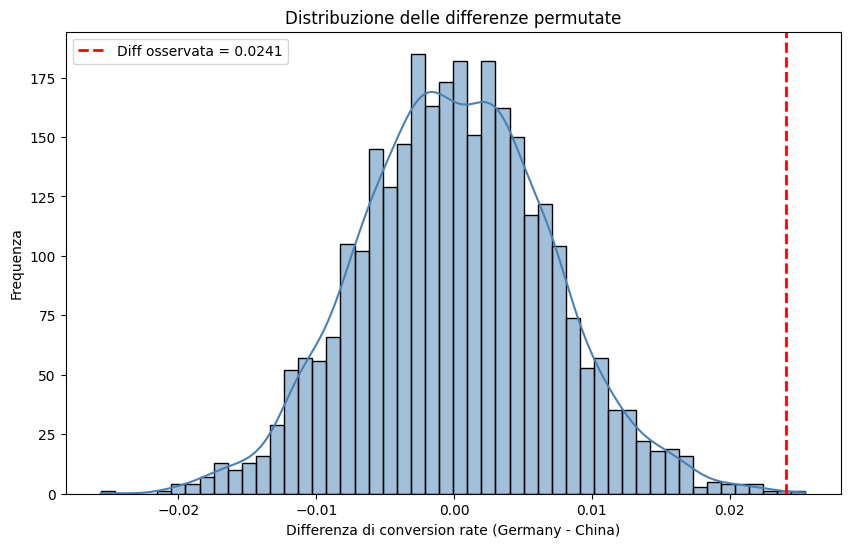

In [33]:
# Visualizziamo la distribuzione delle differenze permutate

plt.figure(figsize=(10,6)) 
sns.histplot(perm_diffs, bins=50, kde=True, color="steelblue")

# Linea della differenza osservata 
plt.axvline(obs_diff, color="red", linestyle="--", linewidth=2, label=f"Diff osservata = {obs_diff:.4f}") 

plt.title("Distribuzione delle differenze permutate") 
plt.xlabel("Differenza di conversion rate (Germany - China)") 
plt.ylabel("Frequenza") 
plt.legend() 
plt.show()

In [ ]:
"""
Osservando la posizione della differenza osservata inizialmente, 
possiamo già dire che la differenza è troppo grande per essere casuale → significativa
"""

In [34]:
# Calcoliamo il p-value: conta quante differenze permutate sono almeno grandi quanto quella osservata
p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
p_value


np.float64(0.0006666666666666666)

In [35]:
# Interpretazione del permutation test Germania vs Cina

print(f"Conversion rate Germania: {cr_germany:.4f}")
print(f"Conversion rate Cina:     {cr_china:.4f}")
print(f"Differenza osservata:     {obs_diff:.4f}")
print(f"P-value (permutation test): {p_value:.4f}\n")

alpha = 0.05

if p_value < alpha:
    print("Conclusione:")
    print("La differenza osservata tra i conversion rate di Germania e Cina è")
    print("statisticamente significativa (p < 0.05).")
    print("È improbabile che una differenza così grande sia dovuta al caso.")
else:
    print("Conclusione:")
    print("La differenza osservata tra i conversion rate di Germania e Cina NON è")
    print("statisticamente significativa (p ≥ 0.05).")
    print("La differenza può essere spiegata dalla variabilità casuale delle sessioni.")


Conversion rate Germania: 0.4975
Conversion rate Cina:     0.4734
Differenza osservata:     0.0241
P-value (permutation test): 0.0007

Conclusione:
La differenza osservata tra i conversion rate di Germania e Cina è
statisticamente significativa (p < 0.05).
È improbabile che una differenza così grande sia dovuta al caso.
